#Introduction to Agents


This notebook is designed to introduce the concept of "agents" in the context of LangChain, a framework for developing applications powered by language models. It walks you through setting up the necessary environment and building a simple agent that can use tools to perform tasks.

# 1. Installation & Setup

## Setup and Installation

The first step is to install the necessary Python libraries. We will use `pip` to install the following packages:

* `langchainhub`: To access pre-built agent prompts and chains from the LangChain hub.
* `langchain-openai`: This library provides the interface to connect with OpenAI's language models, which will be the "brain" of our agent.
* `faiss-cpu`: A library for efficient similarity search and clustering of dense vectors. It's often used for agents that need to perform a vector search.
* `tavily-python`: This library provides a powerful search tool that the agent can use to find information from the web.

In [ ]:
# Install LangChain and related components

!pip install langchainhub
!pip install langchain-openai
!pip install langchain
!pip install beautifulsoup4
!pip install langchain-community
!pip install faiss-cpu
!pip install -U langchain-community tavily-python
!pip gradio_client==0.2.10
!pip install gradio==3.38.0

In [ ]:
import getpass
import os
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI
from langchain.chains import create_retrieval_chain

# 2. API Key Setup
Enter API keys required for authenticating with OpenAI and Tavily service



In [ ]:
# Prompt the user to enter their OpenAI API key securely

os.environ["OPENAI_API_KEY"] = getpass.getpass()

··········


In [ ]:
# Prompt for Tavily API key (for search tool)

os.environ["TAVILY_API_KEY"] = getpass.getpass()

··········


# 3. Document Loading & Vector Store

Here, we load documentation from Langchain and process it so the agent can reference accurate information.

In [ ]:
# LangChain Imports: Imports LangChain components to build agents and tools.

from langchain_community.document_loaders import WebBaseLoader
loader = WebBaseLoader("https://docs.smith.langchain.com/")

docs = loader.load()

# 4. Embeddings & Indexing

In [ ]:
# Create embeddings using OpenAI models

from langchain_openai import OpenAIEmbeddings
embeddings = OpenAIEmbeddings()

In [ ]:
# Split documents and store them in FAISS for efficient search

from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter


text_splitter = RecursiveCharacterTextSplitter()
documents = text_splitter.split_documents(docs)
vector = FAISS.from_documents(documents, embeddings)

In [ ]:
# Display split documents for verification
print(documents)

[Document(metadata={'source': 'https://docs.smith.langchain.com/', 'title': 'Get started with LangSmith - Docs by LangChain', 'language': 'en'}, page_content='Get started with LangSmith - Docs by LangChainDocs by LangChain home pagePythonSearch...⌘KLangSmithPlatform for LLM observability and evaluationOverviewQuickstartsTrace an applicationEvaluate an applicationTest promptsAPI & SDKsAPI referencePython SDKJS/TS SDKPricingPlansPricing FAQDocs by LangChain home pagePythonSearch...⌘KAsk AIGitHubForumForumSearch...NavigationGet started with LangSmithGet startedObservabilityEvaluationPrompt engineeringSelf-hostingAdministrationGet startedObservabilityEvaluationPrompt engineeringSelf-hostingAdministrationGitHubForumGet started with LangSmithCopy pageCopy pageLangSmith is a platform for building production-grade LLM applications. Monitor and evaluate your application, so you can ship quickly and with confidence.\nLangSmith is framework agnostic —\xa0you can use it with or without LangChain’s

# 5. Build Document & Retrieval Chains
Define how prompts and questions are structured, and create chains for document retrieval and response generation.

In [ ]:
# Create chain that feeds documents to an LLM with a specific prompt template

from langchain.chains.combine_documents import create_stuff_documents_chain
# create_stuff_documents_chain :
#  Create a chain for passing a list of Documents to a model.

llm = ChatOpenAI(api_key=os.environ["OPENAI_API_KEY"])
output_parser = StrOutputParser()

prompt = ChatPromptTemplate.from_template("""Answer the following question based only on the provided context:

<context>
{context}
</context>

Question: {input}""", output_parser = output_parser)

document_chain = create_stuff_documents_chain(llm, prompt) # prompt | llm

# 6. Retriever & Agent Construction
Set up tools for searching and create an OpenAI-powered agent that can answer questions or retrieve information.

In [ ]:
# Initialize retriever and wrap in a retrieval chain
retriever = vector.as_retriever()
retrieval_chain = create_retrieval_chain(retriever, document_chain)

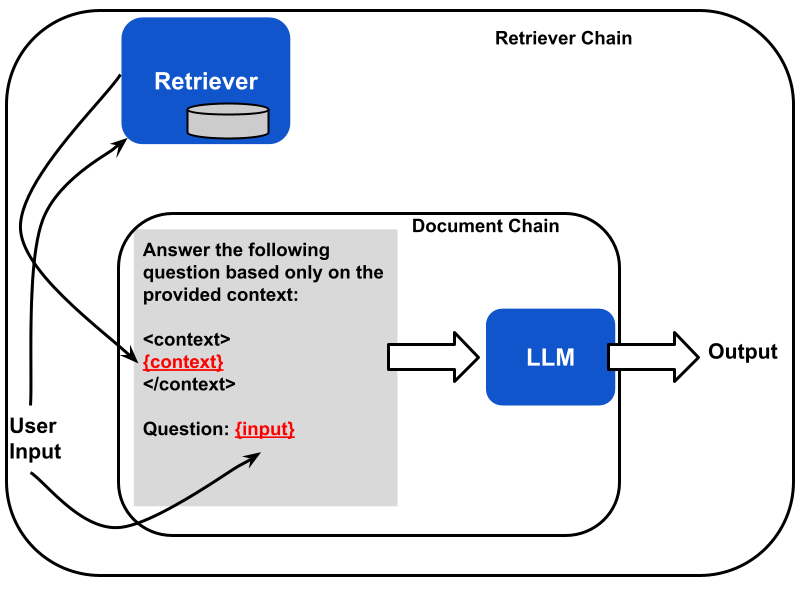

# 7. Tool Definitions
Define additional tools for tasks such as search, addition, multiplication, and exponentiation.

In [ ]:
# Import and define custom tools using decorators
from langchain.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(
    retriever,
    "langsmith_search",
    "Search for information about LangSmith. For any questions about LangSmith, you must use this tool!",
)

NameError: name 'retriever' is not defined

In [ ]:
from langchain_community.tools.tavily_search import TavilySearchResults

search = TavilySearchResults()

<ipython-input-11-2722338889>:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  search = TavilySearchResults()


In [ ]:
tools = [retriever_tool, search]

# 8. Agent Execution
Combine all tools and prompts to enable intelligent question-answering using OpenAI Functions Agent.

In [ ]:
os.environ["LANGCHAIN_API_KEY"] = "Enter_your_LangChain_API"

In [ ]:
from langchain_openai import ChatOpenAI
from langchain import hub
from langchain.agents import create_openai_functions_agent
from langchain.agents import AgentExecutor

# Get the prompt to use - you can modify this!
prompt = hub.pull("hwchase17/openai-functions-agent",
                  api_key=os.environ["LANGCHAIN_API_KEY"])

# You need to set OPENAI_API_KEY environment variable or pass it as argument `api_key`.
llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)
agent = create_openai_functions_agent(llm, tools, prompt)
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

In [ ]:
print(prompt)

input_variables=['agent_scratchpad', 'input'] optional_variables=['chat_history'] input_types={'chat_history': list[typing.Annotated[typing.Union[typing.Annotated[langchain_core.messages.ai.AIMessage, Tag(tag='ai')], typing.Annotated[langchain_core.messages.human.HumanMessage, Tag(tag='human')], typing.Annotated[langchain_core.messages.chat.ChatMessage, Tag(tag='chat')], typing.Annotated[langchain_core.messages.system.SystemMessage, Tag(tag='system')], typing.Annotated[langchain_core.messages.function.FunctionMessage, Tag(tag='function')], typing.Annotated[langchain_core.messages.tool.ToolMessage, Tag(tag='tool')], typing.Annotated[langchain_core.messages.ai.AIMessageChunk, Tag(tag='AIMessageChunk')], typing.Annotated[langchain_core.messages.human.HumanMessageChunk, Tag(tag='HumanMessageChunk')], typing.Annotated[langchain_core.messages.chat.ChatMessageChunk, Tag(tag='ChatMessageChunk')], typing.Annotated[langchain_core.messages.system.SystemMessageChunk, Tag(tag='SystemMessageChunk')]

In [ ]:
print(prompt.input_variables)
print(prompt.messages)

['agent_scratchpad', 'input']
[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are a helpful assistant'), additional_kwargs={}), MessagesPlaceholder(variable_name='chat_history', optional=True), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, template='{input}'), additional_kwargs={}), MessagesPlaceholder(variable_name='agent_scratchpad')]


In [ ]:
print(prompt.messages)

[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are a helpful assistant'), additional_kwargs={}), MessagesPlaceholder(variable_name='chat_history', optional=True), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, template='{input}'), additional_kwargs={}), MessagesPlaceholder(variable_name='agent_scratchpad')]


In [ ]:
for msg in prompt.messages:
    print(msg)
    print("--------")

prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are a helpful assistant') additional_kwargs={}
--------
variable_name='chat_history' optional=True
--------
prompt=PromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, template='{input}') additional_kwargs={}
--------
variable_name='agent_scratchpad'
--------


# 9. Example Usage & Outputs
Demonstrate how to ask questions to LangSmith or fetch general info (e.g., weather).

In [ ]:
result = agent_executor.invoke({"input": "What can I use langsmith for?"})



> Entering new AgentExecutor chain...
LangSmith is a tool that can be used to search for information on a wide range of topics. You can use LangSmith to look up information about people, events, places, and more. It can help you find relevant and accurate information quickly and efficiently. If you have any specific queries or topics you'd like to learn more about, feel free to let me know, and I can use LangSmith to assist you in finding the information you need.

> Finished chain.


In [ ]:
result["output"]

"LangSmith is a tool that can be used to search for information on a wide range of topics. You can use LangSmith to look up information about people, events, places, and more. It can help you find relevant and accurate information quickly and efficiently. If you have any specific queries or topics you'd like to learn more about, feel free to let me know, and I can use LangSmith to assist you in finding the information you need."

In [ ]:
result = agent_executor.invoke({"input": "what is the weather in SF?"})



> Entering new AgentExecutor chain...

Invoking: `tavily_search_results_json` with `{'query': 'weather in San Francisco'}`


[{'title': 'San Francisco weather in November 2025 | Weather25.com', 'url': 'https://www.weather25.com/north-america/usa/california/san-francisco?page=month&month=November', 'content': '# San Francisco weather in November 2025\n\nThe temperatures in San Francisco in November are usually low and can range between **10°C and 18°C**.\n\nYou can expect about **3 to 8 days of rain** in San Francisco during the month of November. It’s a good idea to bring along your umbrella so that you don’t get caught in poor weather.\n\nOur weather forecast can give you a great sense of what weather to expect in **San Francisco in November 2025**. [...] ![Partly cloudy]( "Partly cloudy")\n![Overcast]( "Overcast")\n![Partly cloudy]( "Partly cloudy")\n![Partly cloudy]( "Partly cloudy")\n![Sunny]( "Sunny")\n![Sunny]( "Sunny")\n![Sunny]( "Sunny")\n![Sunny]( "Sunny")\n![Sunny]( "Sunny"

In [ ]:
print(result["output"])

The weather in San Francisco in November is usually low with temperatures ranging between 10°C and 18°C. There can be about 3 to 8 days of rain during the month. It's advisable to bring an umbrella to be prepared for rainy weather.


# 10. Custom Arithmetic Tools

In [ ]:
from langchain_core.tools import tool

Sample implementations of addition, multiplication, and exponentiation as callable agent tools.

In [ ]:
## Add two more tools that perform addition and exponentiation
@tool
def multiply(first_int: int, second_int: int) -> int:
    """Multiply two integers together."""
    return first_int * second_int

@tool
def add(first_int: int, second_int: int) -> int:
    "Add two integers."
    return first_int + second_int


@tool
def exponentiate(base: int, exponent: int) -> int:
    "Exponentiate the base to the exponent power."
    return base**exponent

In [ ]:
print(multiply.name)
print(multiply.description)
print(multiply.args)

multiply
Multiply two integers together.
{'first_int': {'title': 'First Int', 'type': 'integer'}, 'second_int': {'title': 'Second Int', 'type': 'integer'}}


In [ ]:
multiply.invoke({"first_int": 4, "second_int": 5})

20

In [ ]:
from langchain.tools.render import render_text_description

rendered_tools = render_text_description([multiply])
print(rendered_tools)

multiply(first_int: int, second_int: int) -> int - Multiply two integers together.
